In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs


dimensions de X: (100, 2)
dimensions de y: (100, 1)


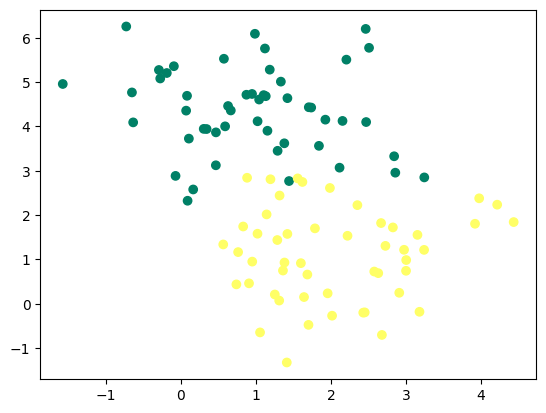

In [58]:
X, y = make_blobs(n_samples=100, n_features=2, centers=2, random_state=0)
y = y.reshape((y.shape[0], 1))

print('dimensions de X:', X.shape)
print('dimensions de y:', y.shape)

plt.scatter(X[:,0], X[:, 1], c=y, cmap='summer')
plt.show()

In [59]:
def initialization(X):
    # weights initialization for each input
    W = np.random.randn(X.shape[1], 1)
    # bias initialization
    b = np.random.randn(1)
    return W, b

In [60]:
W,b = initialization(X)
print(W.shape)
print(W)
print(b.shape)
print(b)


(2, 1)
[[ 2.06048367]
 [-0.76672947]]
(1,)
[1.6191469]


In [61]:
def model(X, W, b):
    Z = X.dot(W) + b 
    A = 1 / (1 + np.exp(-Z))
    return A

In [62]:
A = model(X,W,b)
print(A.shape)

(100, 1)


In [63]:
def log_loss(A, y):
    return 1 / len(y) * np.sum(-y * np.log(A) - (1 - y) * np.log(1 - A))

In [64]:
print(log_loss(A,y))

0.6658763146652196


In [65]:
def gradients(A, X, y):
    dW = 1 / len(y) * np.dot(X.T, A - y)
    db = 1 / len(y) * np.sum(A - y)
    return (dW, db)

In [66]:
dw,db = gradients(A,X,y)
print(dw.shape)
print(db.shape)

(2, 1)
()


In [67]:
def update(dW, db, W, b, learning_rate):
    W = W - learning_rate * dW
    b = b - learning_rate * db
    return (W, b)

In [68]:
def predict(X, W, b):
    A = model(X, W, b)
    print(A)
    return A >= 0.5

In [69]:
from sklearn.metrics import accuracy_score

In [70]:
def artificial_neuron(X, y, learning_rate = 0.1, n_iter = 100):
    # initialisation W, b
    W, b = initialization(X)

    Loss = []

    for i in range(n_iter):
        A = model(X, W, b)
        Loss.append(log_loss(A, y))
        dW, db = gradients(A, X, y)
        W, b = update(dW, db, W, b, learning_rate)

    y_pred = predict(X, W, b)
    print(accuracy_score(y, y_pred))

    plt.plot(Loss)
    plt.show()

    return W, b




[[0.94232941]
 [0.78083603]
 [0.00961408]
 [0.18933166]
 [0.9454103 ]
 [0.36695091]
 [0.08755461]
 [0.91719817]
 [0.06522782]
 [0.86687605]
 [0.0435007 ]
 [0.86431597]
 [0.03333602]
 [0.02800083]
 [0.70908171]
 [0.96816421]
 [0.9854369 ]
 [0.05259761]
 [0.75495681]
 [0.65793903]
 [0.05675785]
 [0.04965487]
 [0.41604595]
 [0.00926296]
 [0.93588446]
 [0.04296364]
 [0.88817832]
 [0.01222943]
 [0.07767776]
 [0.71638245]
 [0.97009202]
 [0.05612823]
 [0.69300332]
 [0.97047395]
 [0.41461212]
 [0.229571  ]
 [0.7803725 ]
 [0.54066857]
 [0.45648049]
 [0.50745943]
 [0.10082333]
 [0.07334321]
 [0.00185514]
 [0.1858194 ]
 [0.23432909]
 [0.8174608 ]
 [0.95814782]
 [0.95369206]
 [0.00906874]
 [0.01429556]
 [0.92801949]
 [0.59996525]
 [0.04669675]
 [0.05008225]
 [0.76624526]
 [0.05401063]
 [0.66581972]
 [0.81798067]
 [0.92962942]
 [0.98583009]
 [0.65682409]
 [0.1869308 ]
 [0.00871394]
 [0.9038107 ]
 [0.01947432]
 [0.37987241]
 [0.05380652]
 [0.57341592]
 [0.91817281]
 [0.27813043]
 [0.19867051]
 [0.91

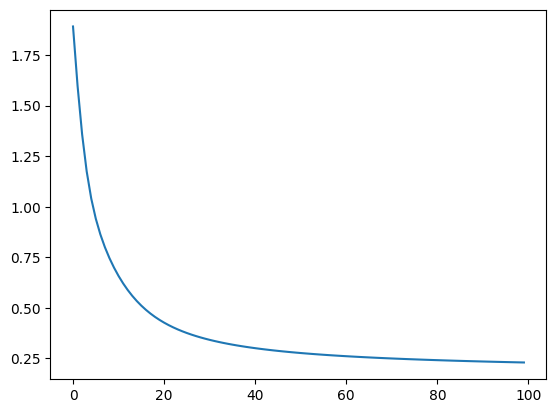

In [71]:
W,b = artificial_neuron(X,y)

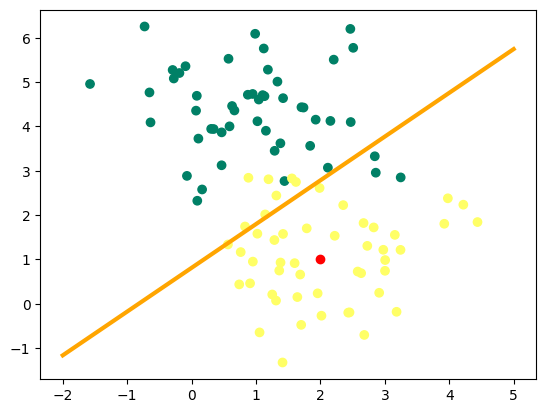

[0.86045833]
[ True]


In [72]:
new_plant = np.array([2,1])

x0 = np.linspace(-2,5,100)
x1 = (-W[0] * x0 - b) / W[1]

plt.scatter(X[:,0], X[:, 1], c=y, cmap='summer')
plt.scatter(new_plant[0],new_plant[1],c='r')
plt.plot(x0,x1,c="orange",lw=3)

plt.show()
print(predict(new_plant,W,b))


In [73]:
import plotly.graph_objects as go

In [74]:
fig = go.Figure(data=[go.Scatter3d(
    x = X[:,0].flatten(),
    y = X[:,1].flatten(),
    z = y.flatten(),
    mode='markers',
    marker=dict(
        size=5,
        color=y.flatten(),
        colorscale='YlGn',
        opacity = 0.8,
        reversescale=True
    )
    
)])

fig.update_layout(template="plotly_dark", margin=dict(l=0, r=0, b=0, t=0))
fig.layout.scene.camera.projection.type = "orthographic"
fig.show()

In [75]:
X0 = np.linspace(X[:,0].min(),X[:,0].max(),100)
X1 = np.linspace(X[:,1].min(),X[:,1].max(),100)
xx0,xx1 = np.meshgrid(X0,X1)
Z = W[0] * xx0 + W[1] * xx1 + b
A = 1 / (1 + np.exp(-Z))

fig = (go.Figure(data=[go.Surface(z=A,x=xx0,y=xx1,colorscale='YlGn',opacity = 0.7,reversescale=True)]))

fig.add_scatter3d(
    x = X[:,0].flatten(),
    y = X[:,1].flatten(),
    z = y.flatten(),
    mode='markers',
    marker=dict(
        size=5,
        color=y.flatten(),
        colorscale='YlGn',
        opacity = 0.8,
        reversescale=True
    ))

fig.update_layout(template="plotly_dark", margin=dict(l=0, r=0, b=0, t=0))
fig.layout.scene.camera.projection.type = "orthographic"
fig.show()